## Relative Sea Level Trends

NOAA Tides & Currents data for Galveston Pier 21 (station 8771450) and New York Battery (station 8158750)

Source: [tidesandcurrents.noaa.gov/sltrends/](https:///tidesandcurrents.noaa.gov/sltrends/)

NOAA Center for Operational Oceanographic Products and Services.

Get data from these websites
 * [Galveston TX Pier 21](https://tidesandcurrents.noaa.gov/sltrends/sltrends_station.shtml?id=8771450)
 * [New York NY Battery](https://tidesandcurrents.noaa.gov/sltrends/sltrends_station.shtml?id=8518750)

Note that our pandas `read_csv()` call is a little wonky as the NOAA CSV files have stray spaces in
the headers that cause problems, so we skip the first row and read by column number rather than 
header.

In [6]:
%matplotlib inline

import os, time
import urllib.request

import sys, math
import numpy as np

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [7]:
figName = 'NOAA_SeaLevel' 

aspect = 3.0 # 4.0/3.0 

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 7
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
axisFontSize = 10 # np.rint(axisFontSize/scaleFac)
labelFontSize = np.rint(labelFontSize/scaleFac)

# Plot filename

plotFile = f'{figName}.{figFmt}'

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

# print a summary (uncomment as needed)

print(f'Filename: {plotFile}')
print(f'Size: {wInches:.2f} x {hInches:.2f}-in ({plotWidth} x {plotHeight} pix)')
print(f'Aspect Ratio: {aspect:.2f}:1')
print(f'Fonts: axes={axisFontSize:.1f} pt, intraplot labels={labelFontSize:.1f}')


Filename: NOAA_SeaLevel.png
Size: 6.00 x 2.00-in (3600.0 x 1200.0 pix)
Aspect Ratio: 3.00:1
Fonts: axes=10.0 pt, intraplot labels=8.0


## NOAA Sea Level Data

Extract data for two sites:
 * [Galveston TX Pier 21](https://tidesandcurrents.noaa.gov/sltrends/sltrends_station.shtml?id=8771450) - Station 8771450
 * [New York NY Battery](https://tidesandcurrents.noaa.gov/sltrends/sltrends_station.shtml?id=8518750) - Station 8518750
 
Extract these data
 * `Year`+`Month`/12 = decimal year
 * `Monthly_MSL` = monthly mean sea level in meters
 * `Linear_Trend` = linear trend
 
More sophisticated plots can also include the 95% confidence limits in the last 2 columns.

In [8]:
stationIDs = ['8771450','8518750']
updateFile = False

for station in stationIDs:
    dataFile = f'{station}_meantrend.csv'
    dataURL = f'https://tidesandcurrents.noaa.gov/sltrends/data/{dataFile}'
    
    oldFile = False
    if not os.path.exists(dataFile):
        updateFile = True
        oldFile = False
        fileAge = 99.99
    else:
        oldFile = True
        fileAge = (time.time() - os.path.getmtime(dataFile))/86400.0
        
    if fileAge >= 1.0:
        updateFile = True
        
    if updateFile:
        try:
            with urllib.request.urlopen(dataURL) as wf:
                raw = wf.read().decode('utf-8')
        except:
            if oldFile:
                print('Problem retrieving updated data, using old file')
            else:
                print('Problem retrieving updated data, no old file to use')
                print('Try retrieving by hand and re-run')
                
        if oldFile:
            os.remove(dataFile)
        f = open(dataFile,'w')
        f.write(raw)
        f.close()   
        print(f'Retrieved updated sea-level data file {dataFile} from NOAA')
    else:
        print(f'Sea-level data file {dataFile} from NOAA is uptodate (<1d old)')        

Sea-level data file 8771450_meantrend.csv from NOAA is uptodate (<1d old)
Sea-level data file 8518750_meantrend.csv from NOAA is uptodate (<1d old)


### Galveston TX Pier 21

Data set: `8771450_meantrend.csv`

Plot the data and the current trend line.  Get the trend slope from the website above.

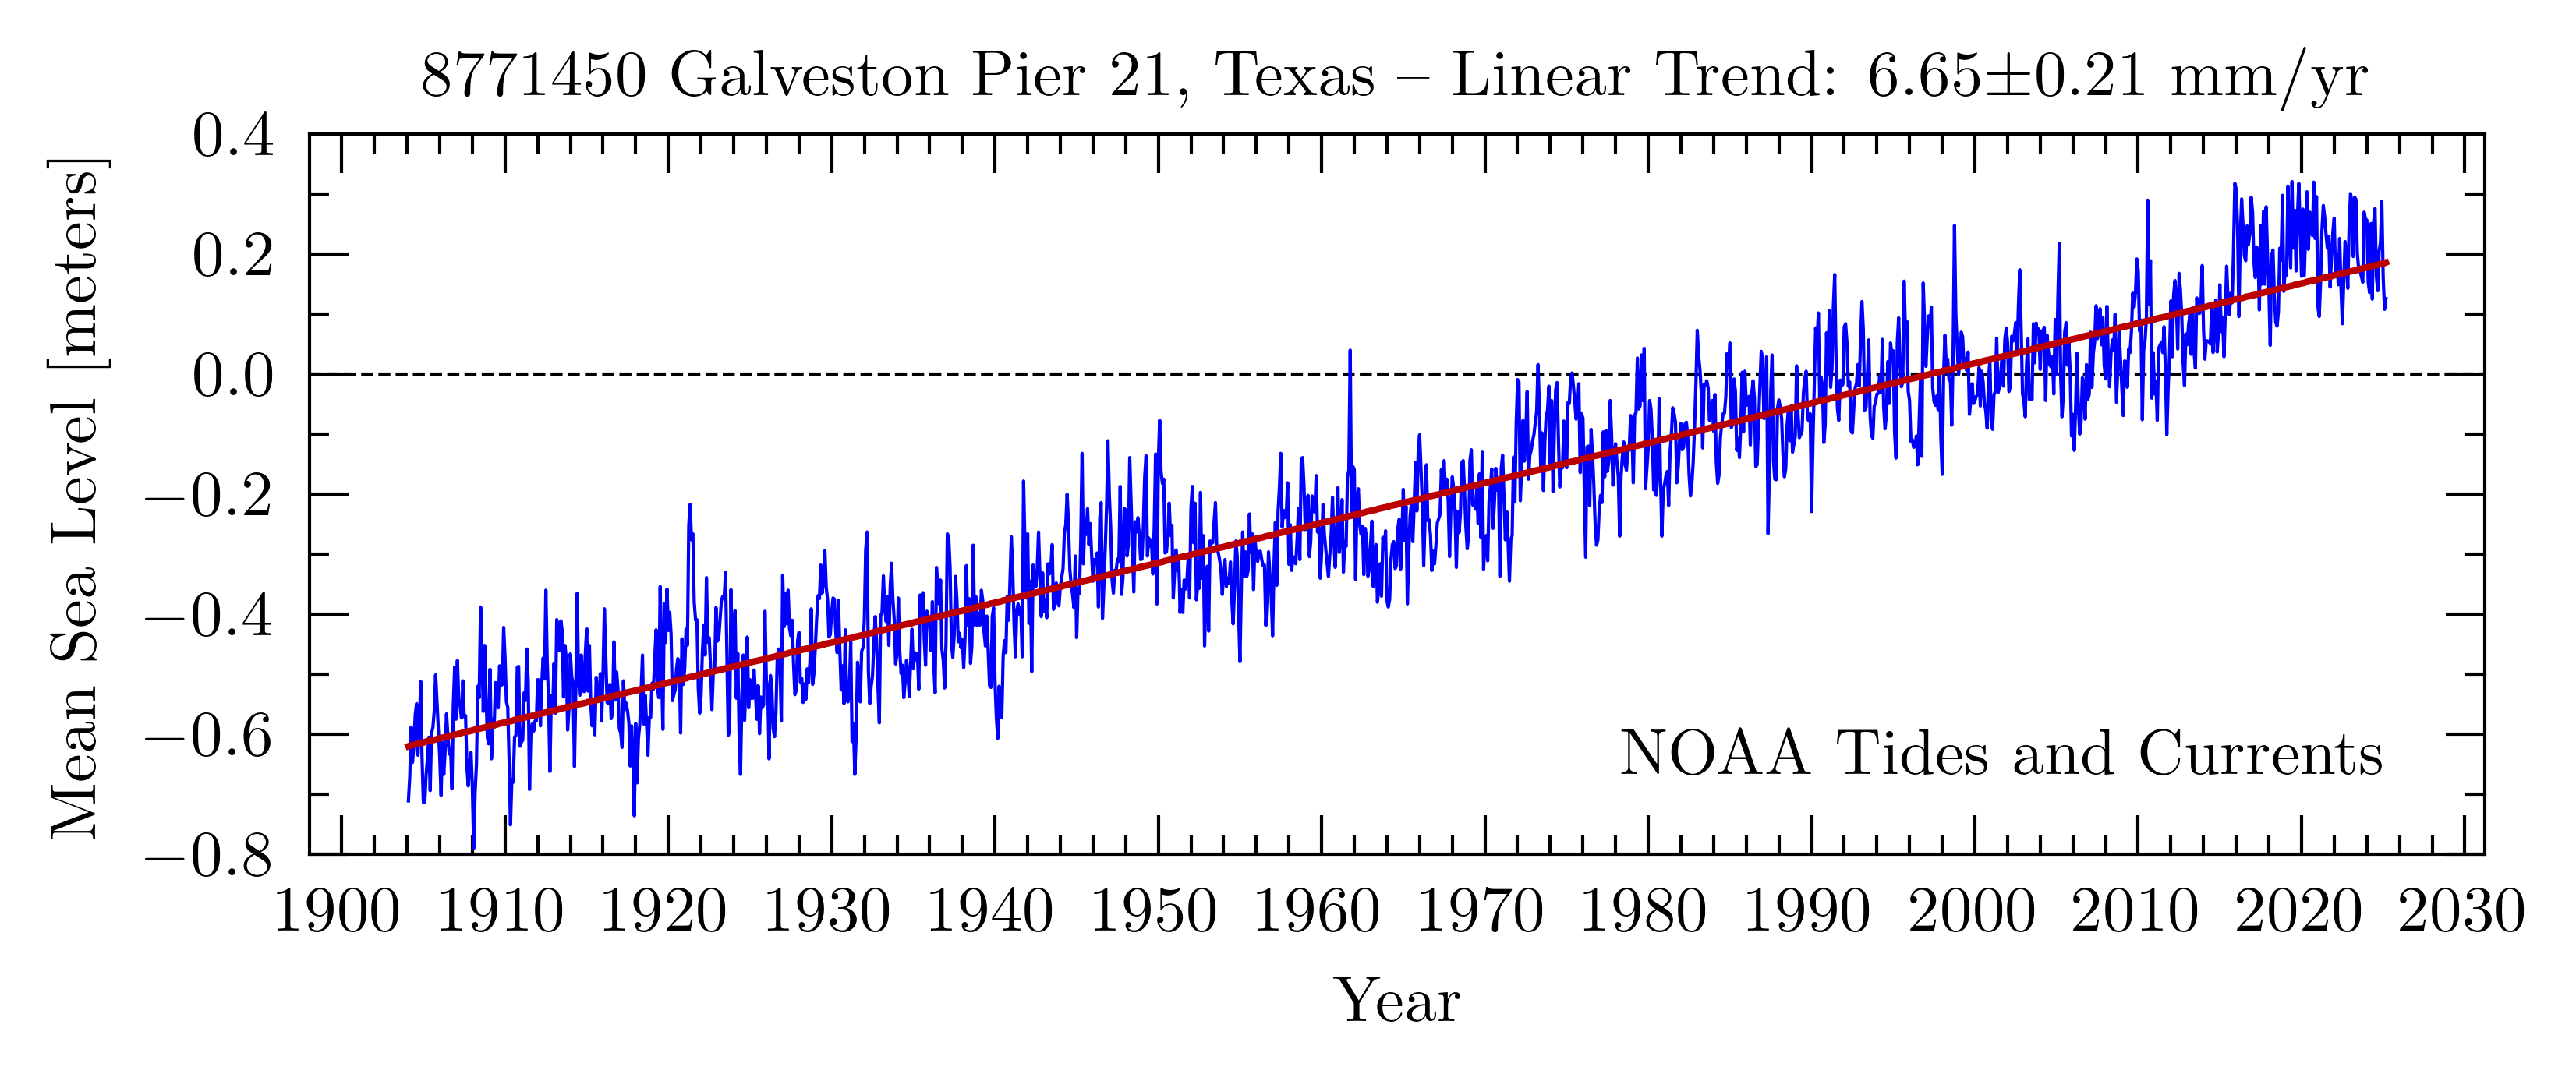

In [9]:
dataFile = '8771450_meantrend.csv'
title = r'8771450 Galveston Pier 21, Texas -- Linear Trend: 6.65$\pm$0.21 mm/yr'
source = 'NOAA Tides and Currents'
skipRows = 6

data = pd.read_csv(dataFile,skiprows=skipRows,header=None)
yr = np.array(data[0])
dataYear = yr[-1]
plotFile = f'NOAA_MSL_GalvenstonTX_{int(dataYear)}.png'

mon = np.array(data[1])
date = yr+(mon/12)
msl = np.array(data[2])
trend = np.array(data[3]) # best-fit trendline

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

dt = np.max(date)-np.min(date)
yrMin = np.min(date) - 0.05*dt
yrMax = np.max(date) + 0.05*dt

dMSL = np.max(msl)-np.min(msl)
mslMin = -0.8 # np.min(msl) - 0.05*dMSL
mslMax = +0.4 # np.max(msl) + 0.05*dMSL

plt.xlim(yrMin,yrMax)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(2))
plt.xlabel(r'Year',fontsize=axisFontSize)

plt.ylim(mslMin,mslMax)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
plt.ylabel(r'Mean Sea Level [meters]',fontsize=axisFontSize)

plt.plot(date,msl,ls='-',color='blue',lw=0.5,zorder=10)
plt.plot(date,trend,ls='-',color='#bb0000',lw=1,zorder=10)
plt.hlines(0,yrMin,yrMax,ls=['--'],colors=['black'],lw=0.5,zorder=8)

plt.title(title,fontsize=10)

# Data Source

plt.text(yrMax-0.05*dt,mslMin+0.1*dMSL,source,va='bottom',ha='right',fontsize=10)

# Make the plot

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()

### New York Batttery

Data set: `8518750_meantrend.csv`

Plot the data and the current trend line.  Get the trend slope from the website above.

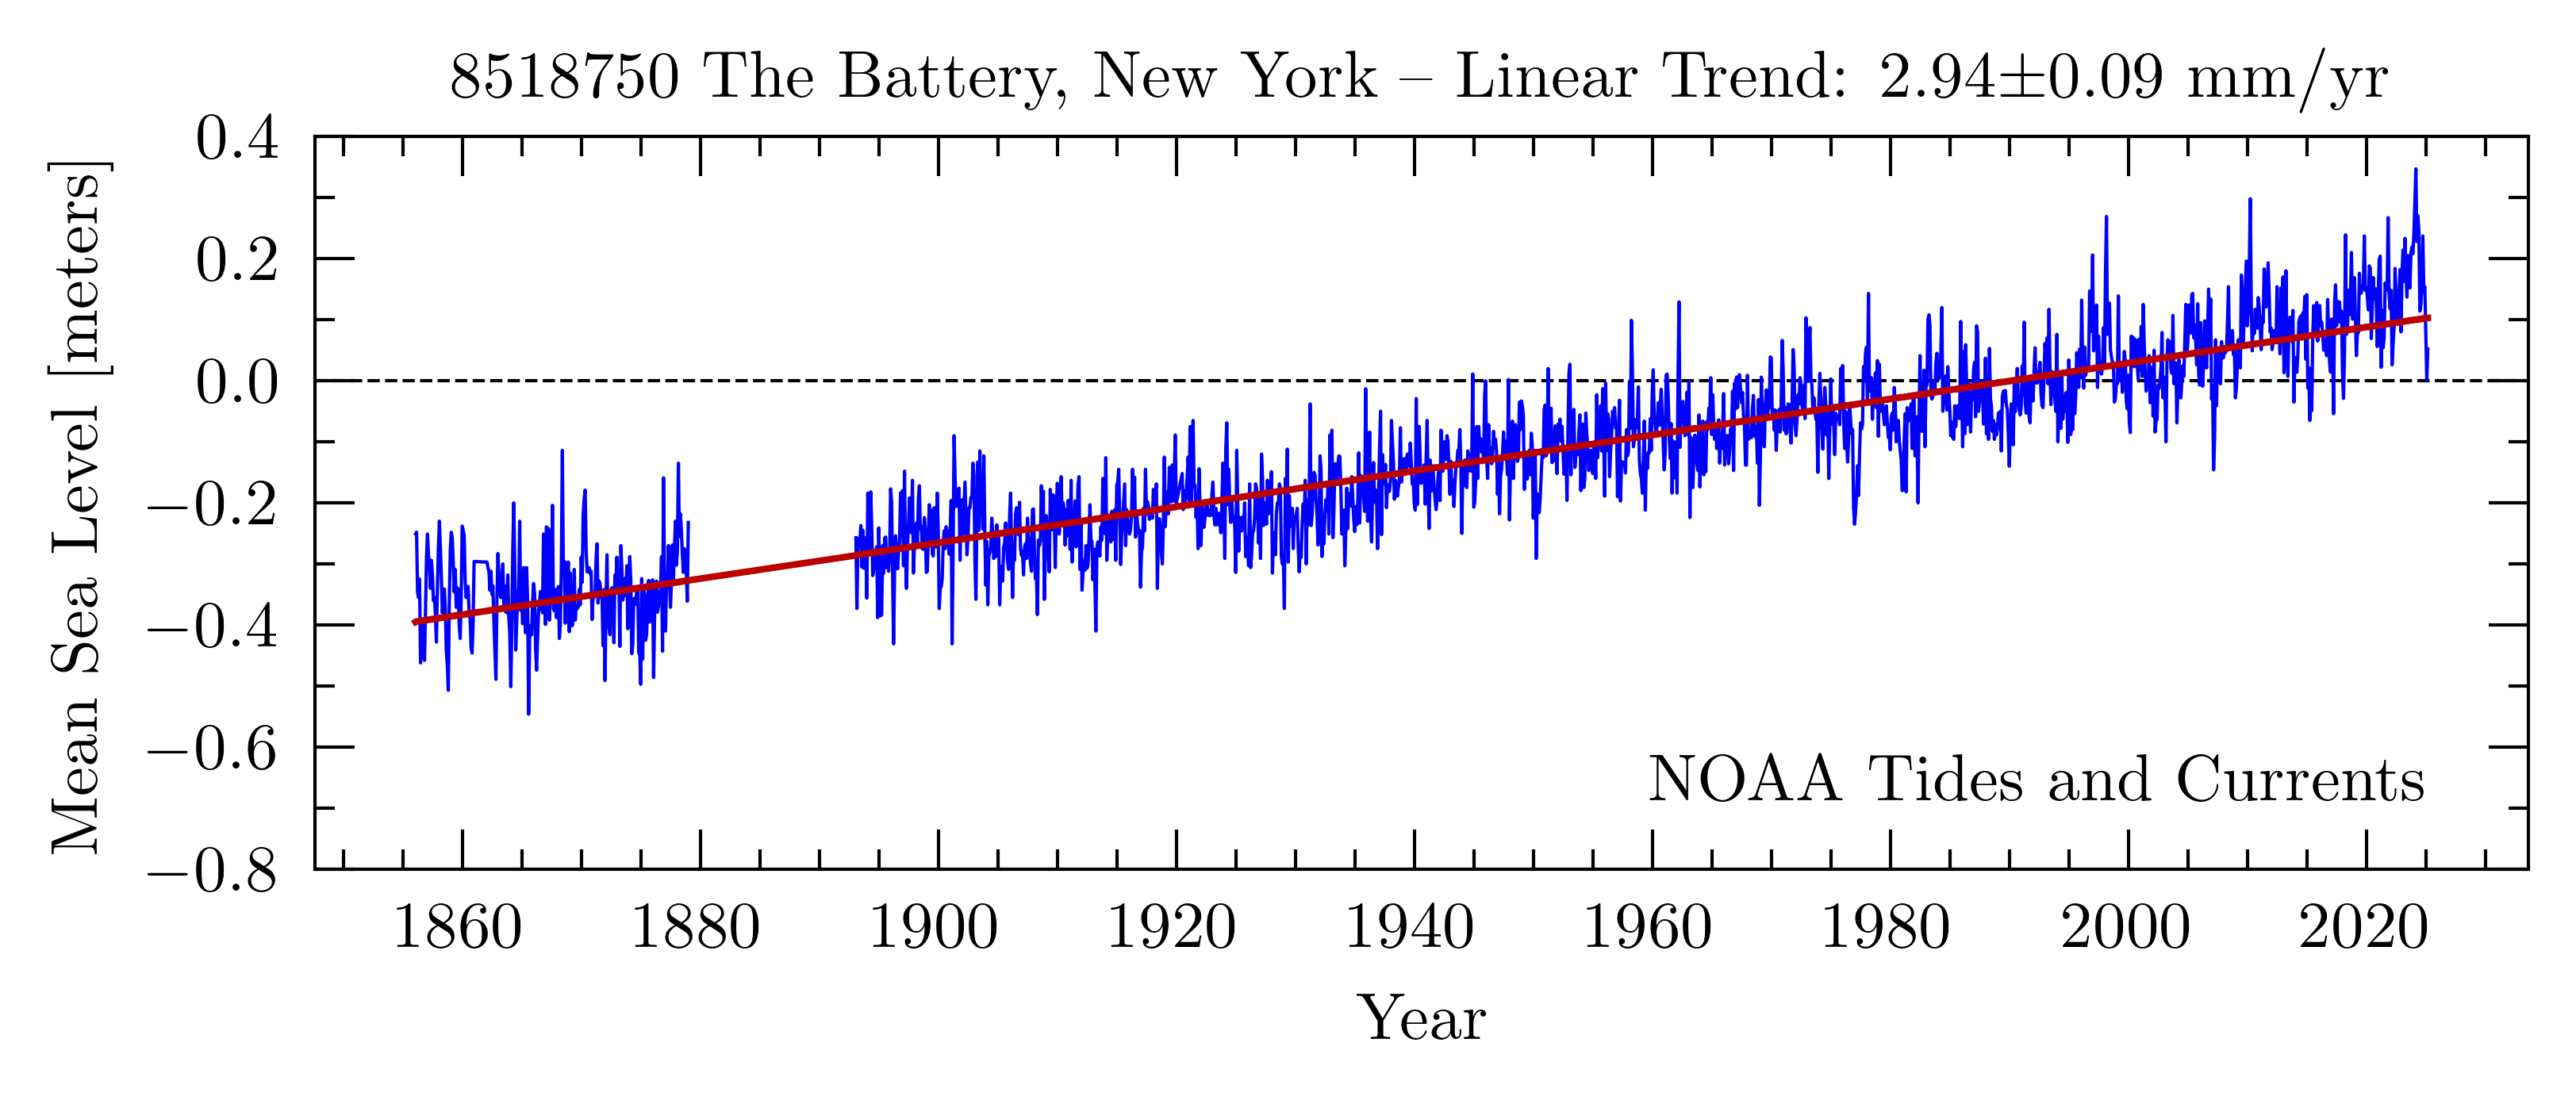

In [10]:
dataFile = '8518750_meantrend.csv'
title = r'8518750 The Battery, New York -- Linear Trend: 2.94$\pm$0.09 mm/yr'
source = 'NOAA Tides and Currents'
skipRows = 6

data = pd.read_csv(dataFile,skiprows=skipRows,header=None)
yr = np.array(data[0])
dataYear = yr[-1]
plotFile = f'NOAA_MSL_BatteryNY_{int(dataYear)}.png'

mon = np.array(data[1])
date = yr+(mon/12)
msl = np.array(data[2])
trend = np.array(data[3]) # best-fit trendline

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

dt = np.max(date)-np.min(date)
yrMin = np.min(date) - 0.05*dt
yrMax = np.max(date) + 0.05*dt

dMSL = np.max(msl)-np.min(msl)
mslMin = -0.8 # np.min(msl) - 0.05*dMSL
mslMax = +0.4 # np.max(msl) + 0.05*dMSL

plt.xlim(yrMin,yrMax)
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_minor_locator(MultipleLocator(5))
plt.xlabel(r'Year',fontsize=axisFontSize)

plt.ylim(mslMin,mslMax)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
plt.ylabel(r'Mean Sea Level [meters]',fontsize=axisFontSize)

pre1880 = np.where(date<1880)
plt.plot(date[pre1880],msl[pre1880],ls='-',color='blue',lw=0.5,zorder=10)
post1880 = np.where(date>1880)
plt.plot(date[post1880],msl[post1880],ls='-',color='blue',lw=0.5,zorder=10)

plt.plot(date,trend,ls='-',color='#bb0000',lw=1,zorder=10)
plt.hlines(0,yrMin,yrMax,ls=['--'],colors=['black'],lw=0.5,zorder=8)

plt.title(title,fontsize=10)

# Data Source

plt.text(yrMax-0.05*dt,mslMin+0.1*dMSL,source,va='bottom',ha='right',fontsize=10)

# Make the plot

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()